# Epistasis Heatmap — Edge Perturbation Analysis

**Protocol**: Select the top-10 architectures (by accuracy) from the proposed archive.  
For each architecture, each edge $e \in \{0..5\}$ is perturbed to all 4 alternative operations $\{0..4\} \setminus \{\text{original}\}$.  
Fitness drop is defined as:
$$\Delta F(e, o) = \text{Acc}_{\text{original}} - \text{Acc}_{\text{perturbed}}$$
A high $\Delta F$ indicates that edge $e$ is **sensitive** (epistatic): changing its operation strongly degrades performance.

The heatmap reveals which edges form the **architectural backbone** — exactly the edges that discrete PSO must handle carefully (vs GA's random mutation).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.api.hw_nas_wrapper import HWNASApi

DATA_PATH   = PROJECT_ROOT / "data" / "HW-NAS-Bench-v1_0.pickle"
RESULTS_DIR = PROJECT_ROOT / "results"
DEVICE      = "edgegpu_latency"
DATASET     = "cifar10"
TOP_K       = 10
OPS         = ["none", "skip_connect", "avg_pool_3x3", "nor_conv_1x1", "nor_conv_3x3"]
N_OPS       = len(OPS)   # 5
N_EDGES     = 6

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
})

# HWNASApi auto-detects data/nas201_accuracy_cache.npz (~1 MB).
# Run scripts/extract_nas201_accuracy.py once to generate the cache from the .pth file.
api = HWNASApi(str(DATA_PATH))
_mode = "ground-truth" if api._acc_cache is not None else "structural proxy"
print(f"HWNASApi loaded — accuracy mode: {_mode}")


Loading benchmark from /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/data/HW-NAS-Bench-v1_0.pickle...


/home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/src/api/hw_nas_wrapper.py:38: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  self.data = pickle.load(f)


Accuracy cache loaded (183 KB) — ground-truth mode active.
Benchmark loaded. Available devices: ['nasbench201', 'fbnet']
HWNASApi loaded — accuracy mode: ground-truth


In [2]:
# ── Load proposed archives ────────────────────────────────────────────────
archives = []
for p in sorted(RESULTS_DIR.glob("proposed/proposed_res_*.json")):
    payload = json.loads(p.read_text())
    archives.extend(payload["archive"])

if not archives:
    print("No proposed archives found. Run scripts/run_search.py first.")
else:
    print(f"Total evaluations loaded: {len(archives)}")

# Sort descending by accuracy; take top-K unique architectures
seen = set()
top_entries = []
for e in sorted(archives, key=lambda x: x["accuracy"], reverse=True):
    key = tuple(e["arch"])
    if key not in seen:
        seen.add(key)
        top_entries.append(e)
    if len(top_entries) >= TOP_K:
        break

print(f"Top-{TOP_K} unique architectures selected.")
for i, e in enumerate(top_entries):
    print(f"  [{i+1}] arch={e['arch']}  acc={e['accuracy']:.2f}  lat={e['latency']:.3f}")

Total evaluations loaded: 2000
Top-10 unique architectures selected.
  [1] arch=[4, 4, 4, 1, 4, 3]  acc=94.37  lat=6.810
  [2] arch=[4, 4, 4, 1, 4, 4]  acc=94.36  lat=7.050
  [3] arch=[4, 3, 4, 1, 3, 3]  acc=94.31  lat=6.832
  [4] arch=[3, 4, 4, 1, 4, 4]  acc=94.30  lat=6.805
  [5] arch=[4, 4, 2, 1, 4, 3]  acc=94.25  lat=6.504
  [6] arch=[4, 4, 0, 1, 4, 4]  acc=94.24  lat=7.348
  [7] arch=[4, 4, 0, 1, 3, 4]  acc=94.21  lat=5.482
  [8] arch=[4, 4, 3, 1, 4, 3]  acc=94.19  lat=6.747
  [9] arch=[4, 4, 1, 1, 4, 4]  acc=94.18  lat=6.118
  [10] arch=[4, 4, 2, 1, 3, 4]  acc=94.09  lat=6.504


In [3]:
# ── Perturbation experiment ───────────────────────────────────────────────
# delta_matrix[op, edge] = mean accuracy drop when edge is changed to 'op'
# Uses api.query_accuracy(): ground-truth NAS-Bench-201 accuracy if .pth is
# available, otherwise the structural proxy (operation-richness fallback).

def get_fitness(arch: np.ndarray) -> float:
    """Fitness = test accuracy (ground-truth or proxy, higher is better)."""
    return api.query_accuracy(arch, dataset=DATASET)

# delta[op_idx, edge_idx] accumulator
delta_sum   = np.zeros((N_OPS, N_EDGES), dtype=np.float64)
delta_count = np.zeros((N_OPS, N_EDGES), dtype=np.int32)

for entry in top_entries:
    arch_orig = np.array(entry["arch"], dtype=np.int64)
    f_orig    = get_fitness(arch_orig)

    for edge in range(N_EDGES):
        orig_op = int(arch_orig[edge])
        alt_ops = [o for o in range(N_OPS) if o != orig_op]

        for op in alt_ops:
            perturbed         = arch_orig.copy()
            perturbed[edge]   = op
            f_perturbed       = get_fitness(perturbed)
            delta             = f_orig - f_perturbed   # positive = accuracy drop
            delta_sum[op, edge]   += delta
            delta_count[op, edge] += 1

# Average delta; cells with no observations stay NaN
with np.errstate(invalid="ignore"):
    delta_matrix = np.where(delta_count > 0,
                            delta_sum / np.maximum(delta_count, 1),
                            np.nan)

print("Perturbation matrix computed.")
print(f"Shape: {delta_matrix.shape}  (ops × edges)")


Perturbation matrix computed.
Shape: (5, 6)  (ops × edges)


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/epistasis_heatmap.pdf


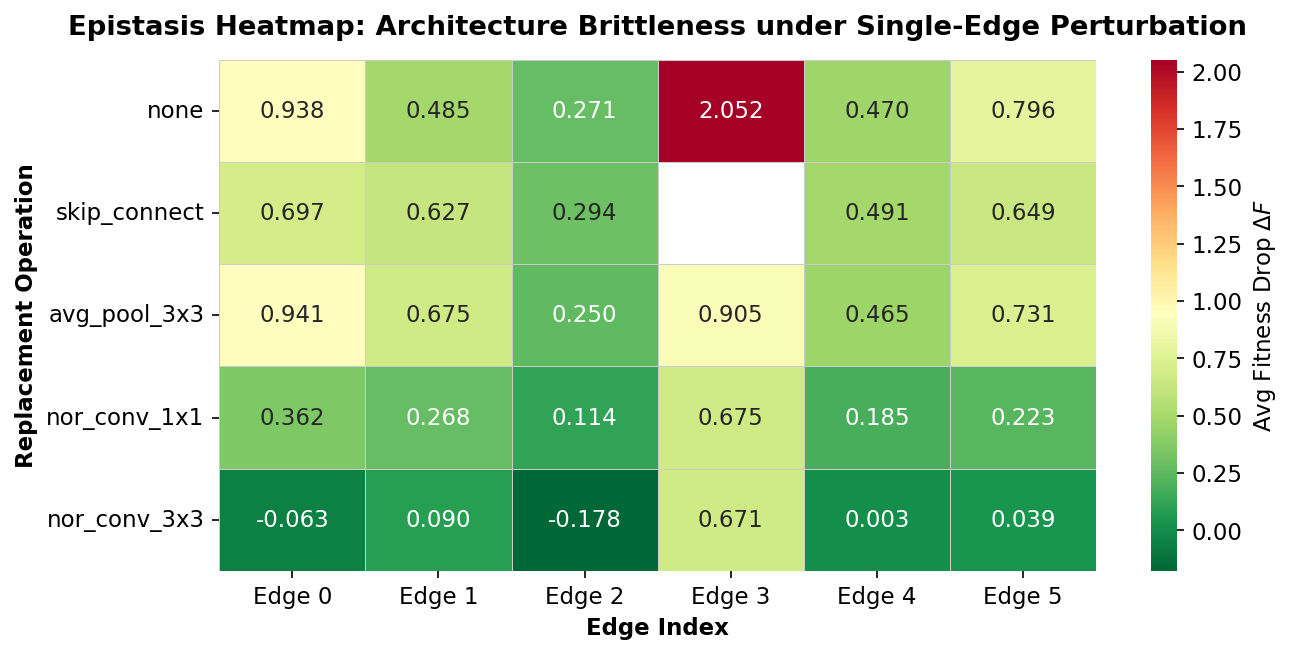

In [4]:
# ── Heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

sns.heatmap(
    delta_matrix,
    ax=ax,
    cmap="RdYlGn_r",        # red = high drop (brittle), green = robust
    annot=True,
    fmt=".3f",
    linewidths=0.4,
    linecolor="#cccccc",
    xticklabels=[f"Edge {i}" for i in range(N_EDGES)],
    yticklabels=OPS,
    cbar_kws={"label": r"Avg Fitness Drop $\Delta F$"},
    mask=np.isnan(delta_matrix),
)

ax.set_xlabel("Edge Index", fontweight="bold")
ax.set_ylabel("Replacement Operation", fontweight="bold")
ax.set_title(
    r"Epistasis Heatmap: Architecture Brittleness under Single-Edge Perturbation",
    fontweight="bold", pad=12,
)
fig.tight_layout()

out = PROJECT_ROOT / "results" / "epistasis_heatmap.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches="tight")
print(f"Saved → {out}")
plt.show()

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/epistasis_marginals.pdf


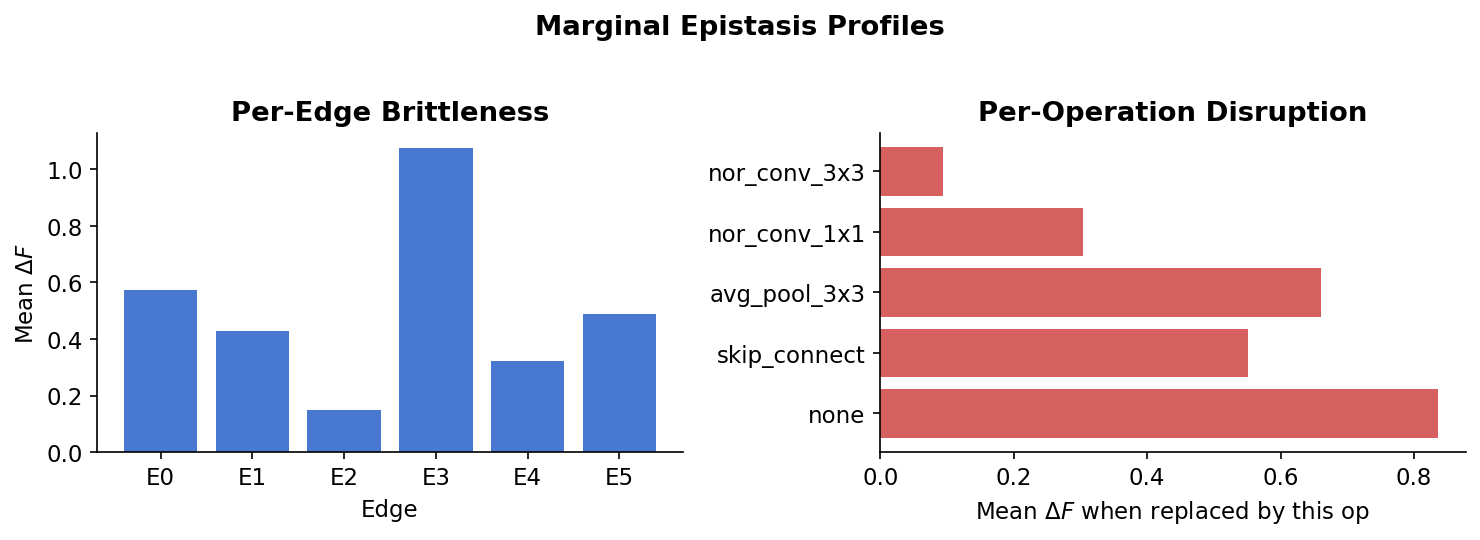

In [5]:
# ── Marginal brittleness: per-edge and per-operation summaries ────────────
edge_brittleness = np.nanmean(delta_matrix, axis=0)   # mean drop per edge
op_brittleness   = np.nanmean(delta_matrix, axis=1)   # mean drop per replacement op

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(range(N_EDGES), edge_brittleness, color="#4878CF")
axes[0].set_xticks(range(N_EDGES))
axes[0].set_xticklabels([f"E{i}" for i in range(N_EDGES)])
axes[0].set_xlabel("Edge")
axes[0].set_ylabel(r"Mean $\Delta F$")
axes[0].set_title("Per-Edge Brittleness", fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(range(N_OPS), op_brittleness, color="#D65F5F")
axes[1].set_yticks(range(N_OPS))
axes[1].set_yticklabels(OPS)
axes[1].set_xlabel(r"Mean $\Delta F$ when replaced by this op")
axes[1].set_title("Per-Operation Disruption", fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Marginal Epistasis Profiles", fontweight="bold", y=1.02)
fig.tight_layout()

out2 = PROJECT_ROOT / "results" / "epistasis_marginals.pdf"
fig.savefig(out2, bbox_inches="tight")
print(f"Saved → {out2}")
plt.show()